# Classification with neural network

## 1. Prepare data

In [1]:


from sklearn.datasets import make_circles

nb_samples=1000

X, y = make_circles(n_samples= nb_samples, noise=0.03, random_state=42)
len(X), len(y)

(1000, 1000)

In [2]:
print(f"First 5 Samples of X:\n {X[:5]}")
print(f"First 5 Samples of y:\n {y[:5]}")

First 5 Samples of X:
 [[ 0.75424625  0.23148074]
 [-0.75615888  0.15325888]
 [-0.81539193  0.17328203]
 [-0.39373073  0.69288277]
 [ 0.44220765 -0.89672343]]
First 5 Samples of y:
 [1 1 1 1 0]


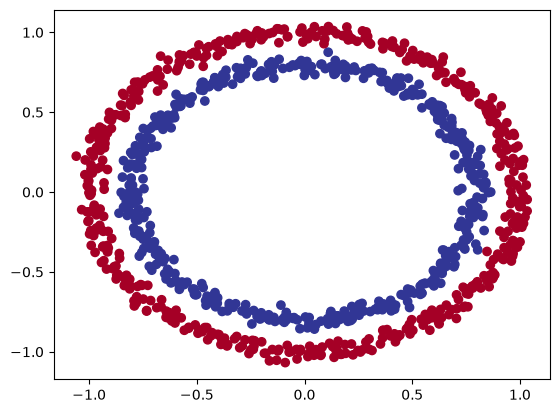

In [3]:
import matplotlib.pyplot as plt
plt.scatter(x=X[:, 0], 
            y=X[:, 1], 
            c=y, 
            cmap=plt.cm.RdYlBu);

#### The goal is to identify if one element is on the blue or red circle

Shapes of the data set: shows we have 2 inputs and one output

In [4]:

X.shape, y.shape

((1000, 2), (1000,))

In [5]:
# Turn data into tensors and create train and test splits
import torch
X= torch.from_numpy(X).type(torch.float)
y= torch.from_numpy(y).type(torch.float)
X[:5],y[:5]

(tensor([[ 0.7542,  0.2315],
         [-0.7562,  0.1533],
         [-0.8154,  0.1733],
         [-0.3937,  0.6929],
         [ 0.4422, -0.8967]]),
 tensor([1., 1., 1., 1., 0.]))

In [6]:
# split in training and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)
len(X_train), len(y_train), len(X_test), len(y_test)

(800, 800, 200, 200)

In [7]:
# Build the model: on CPU
from torch import nn

device = torch.device("mps") if torch.backends.mps.is_available() else "cpu"
device

device(type='mps')

#### Create a 5 hidden units in the neuron layer. 
This amount depends of the dat set. Bigger numbers are good until a certain limit.

In [8]:

class CircleModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1= nn.Linear(in_features=2, out_features=5)
        self.layer_2= nn.Linear(in_features=5, out_features=1)
        
    def forward(self,x):
        return self.layer_2(self.layer_1(x))
    
model_0 = CircleModel().to(device)
model_0

CircleModel(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

see [Tensorflow playground](https://playground.tensorflow.org/#activation=tanh&batchSize=10&dataset=circle&regDataset=reg-plane&learningRate=0.03&regularizationRate=0&noise=0&networkShape=4,2&seed=0.93055&showTestData=false&discretize=false&percTrainData=50&x=true&y=true&xTimesY=false&xSquared=false&ySquared=false&cosX=false&sinX=false&cosY=false&sinY=false&collectStats=false&problem=classification&initZero=false&hideText=false) to play with Neural Network visually.

#### make prediction on the model

In [9]:
untrained_preds=model_0(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])



First 10 predictions:
tensor([[0.7548],
        [0.6787],
        [0.8006],
        [0.7425],
        [0.5566],
        [0.5120],
        [0.4911],
        [0.4514],
        [0.8109],
        [0.6709]], device='mps:0', grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In previous the label are not the same, and all close to zero. So we need to add loss function and optimizer
To select a loss function looks at the different type in: https://pytorch.org/docs/stable/nn.html#loss-functions

For binary classification we need a loss function for binary selection. The Binary Cross Entropy can be used

In [10]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer= torch.optim.SGD(params=model_0.parameters(), lr=0.1)


In [11]:
# Calculate accuracy (a classification metric)
def accuracy_fn(y_true, y_pred):
    correct = torch.eq(y_true, y_pred).sum().item() # torch.eq() calculates if two tensors are equal
    acc = (correct / len(y_pred)) * 100 
    return acc

In [12]:
# Training the model
torch.manual_seed(42)
epochs=100
# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):
    model_0.train()
    # 1. Forward pass (model outputs = raw logits)
    y_logits = model_0(X_train).squeeze() 
    # turn logits -> predicted probabilities -> predicted labels
    y_pred = torch.round(torch.sigmoid(y_logits)) 
    # 2. Calculate loss/accuracy
    loss = loss_fn(y_logits, # Using nn.BCEWithLogitsLoss works with raw logits
                   y_train) 
    acc = accuracy_fn(y_true=y_train, 
                      y_pred=y_pred)
    # 3. Optimizer zero grad
    optimizer.zero_grad()

    # 4. Loss backwards
    loss.backward()

    # 5. Optimizer step
    optimizer.step()
    
    ### Testing
    model_0.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_0(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.74899, Accuracy: 50.00% | Test loss: 0.73995, Test acc: 50.00
Epoch: 10 | Loss: 0.70856, Accuracy: 50.00% | Test loss: 0.70459, Test acc: 50.00
Epoch: 20 | Loss: 0.69775, Accuracy: 50.00% | Test loss: 0.69559, Test acc: 50.00
Epoch: 30 | Loss: 0.69471, Accuracy: 56.12% | Test loss: 0.69347, Test acc: 57.50
Epoch: 40 | Loss: 0.69377, Accuracy: 52.25% | Test loss: 0.69315, Test acc: 56.00
Epoch: 50 | Loss: 0.69343, Accuracy: 49.88% | Test loss: 0.69328, Test acc: 55.00
Epoch: 60 | Loss: 0.69327, Accuracy: 49.62% | Test loss: 0.69351, Test acc: 53.50
Epoch: 70 | Loss: 0.69318, Accuracy: 50.25% | Test loss: 0.69374, Test acc: 50.50
Epoch: 80 | Loss: 0.69313, Accuracy: 50.88% | Test loss: 0.69394, Test acc: 49.50
Epoch: 90 | Loss: 0.69309, Accuracy: 50.88% | Test loss: 0.69411, Test acc: 49.50


Let's make a plot of our model's predictions, the data it's trying to predict on and the decision boundary it's creating for whether something is class 0 or class 1.


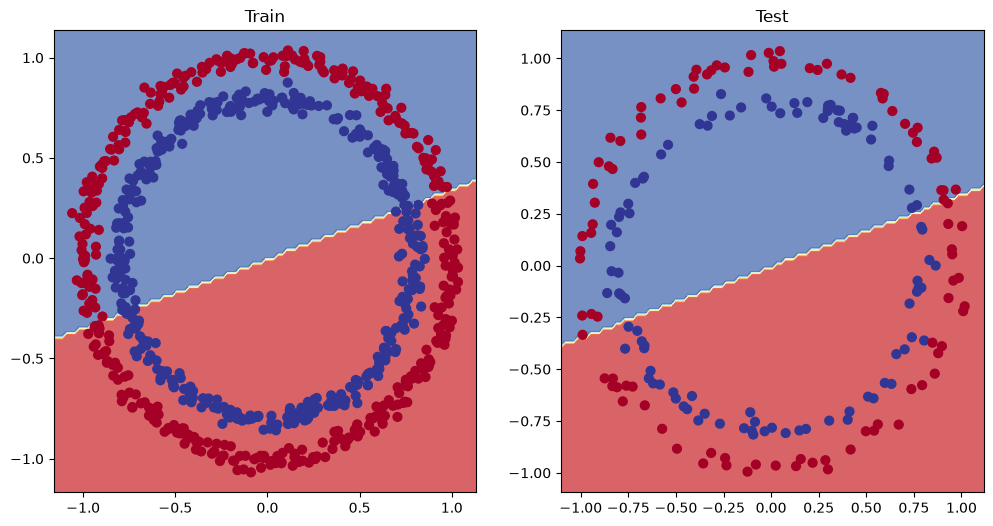

In [13]:
from helper_functions import plot_predictions, plot_decision_boundary
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_0, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_0, X_test, y_test)

The model is underfitting. Need to improve it. 

# Improve model
Add more layers to the NN, add more features, add ReLU between layers.

In [14]:
class CircleModel_1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1= nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)
        self.relu = nn.ReLU()
       
        
    def forward(self,x):
        return self.layer_3(self.relu(self.layer_2(self.relu(self.layer_1(x)))))
    
model_1 = CircleModel_1().to(device)
model_1


CircleModel_1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
  (relu): ReLU()
)

In [15]:
device

device(type='mps')

In [16]:
loss_fn=nn.BCEWithLogitsLoss()
optimizer= torch.optim.SGD(params=model_1.parameters(), lr=0.1)
torch.manual_seed(42)
epochs=100
# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)
epochs=1000
for epoch in range(epochs):
    y_logits = model_1(X_train).squeeze()
    y_preds = torch.round(torch.sigmoid(y_logits))
    loss = loss_fn(y_logits,y_train)
    acc = accuracy_fn(y_true=y_train, y_pred=y_pred)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model_1.eval()
    with torch.inference_mode():
        # 1. Forward pass
        test_logits = model_1(X_test).squeeze() 
        test_pred = torch.round(torch.sigmoid(test_logits))
        # 2. Caculate loss/accuracy
        test_loss = loss_fn(test_logits,y_test)
        test_acc = accuracy_fn(y_true=y_test, y_pred=test_pred)

    # Print out what's happening every 10 epochs
    if epoch % 10 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.5f}, Accuracy: {acc:.2f}% | Test loss: {test_loss:.5f}, Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.69295, Accuracy: 50.88% | Test loss: 0.69319, Test acc: 50.00
Epoch: 10 | Loss: 0.69248, Accuracy: 50.88% | Test loss: 0.69260, Test acc: 50.00
Epoch: 20 | Loss: 0.69225, Accuracy: 50.88% | Test loss: 0.69231, Test acc: 56.50
Epoch: 30 | Loss: 0.69209, Accuracy: 50.88% | Test loss: 0.69212, Test acc: 68.00
Epoch: 40 | Loss: 0.69195, Accuracy: 50.88% | Test loss: 0.69195, Test acc: 71.00
Epoch: 50 | Loss: 0.69181, Accuracy: 50.88% | Test loss: 0.69177, Test acc: 58.00
Epoch: 60 | Loss: 0.69168, Accuracy: 50.88% | Test loss: 0.69161, Test acc: 54.50
Epoch: 70 | Loss: 0.69155, Accuracy: 50.88% | Test loss: 0.69146, Test acc: 53.00
Epoch: 80 | Loss: 0.69141, Accuracy: 50.88% | Test loss: 0.69132, Test acc: 53.00
Epoch: 90 | Loss: 0.69128, Accuracy: 50.88% | Test loss: 0.69117, Test acc: 53.00
Epoch: 100 | Loss: 0.69115, Accuracy: 50.88% | Test loss: 0.69102, Test acc: 52.50
Epoch: 110 | Loss: 0.69103, Accuracy: 50.88% | Test loss: 0.69088, Test acc: 53.50
Epoch: 120 | Lo

Epoch: 190 | Loss: 0.68993, Accuracy: 50.88% | Test loss: 0.68958, Test acc: 55.00
Epoch: 200 | Loss: 0.68977, Accuracy: 50.88% | Test loss: 0.68940, Test acc: 55.00
Epoch: 210 | Loss: 0.68962, Accuracy: 50.88% | Test loss: 0.68921, Test acc: 55.00
Epoch: 220 | Loss: 0.68946, Accuracy: 50.88% | Test loss: 0.68902, Test acc: 56.00
Epoch: 230 | Loss: 0.68929, Accuracy: 50.88% | Test loss: 0.68882, Test acc: 56.00
Epoch: 240 | Loss: 0.68912, Accuracy: 50.88% | Test loss: 0.68861, Test acc: 56.00
Epoch: 250 | Loss: 0.68894, Accuracy: 50.88% | Test loss: 0.68840, Test acc: 56.00
Epoch: 260 | Loss: 0.68875, Accuracy: 50.88% | Test loss: 0.68818, Test acc: 56.00
Epoch: 270 | Loss: 0.68856, Accuracy: 50.88% | Test loss: 0.68795, Test acc: 56.00
Epoch: 280 | Loss: 0.68836, Accuracy: 50.88% | Test loss: 0.68772, Test acc: 56.00
Epoch: 290 | Loss: 0.68816, Accuracy: 50.88% | Test loss: 0.68748, Test acc: 56.00
Epoch: 300 | Loss: 0.68795, Accuracy: 50.88% | Test loss: 0.68723, Test acc: 56.00
Epoc

Epoch: 400 | Loss: 0.68517, Accuracy: 50.88% | Test loss: 0.68411, Test acc: 56.50
Epoch: 410 | Loss: 0.68481, Accuracy: 50.88% | Test loss: 0.68373, Test acc: 56.50
Epoch: 420 | Loss: 0.68444, Accuracy: 50.88% | Test loss: 0.68332, Test acc: 56.00
Epoch: 430 | Loss: 0.68406, Accuracy: 50.88% | Test loss: 0.68289, Test acc: 56.00
Epoch: 440 | Loss: 0.68367, Accuracy: 50.88% | Test loss: 0.68245, Test acc: 56.00
Epoch: 450 | Loss: 0.68326, Accuracy: 50.88% | Test loss: 0.68198, Test acc: 56.00
Epoch: 460 | Loss: 0.68284, Accuracy: 50.88% | Test loss: 0.68150, Test acc: 56.00
Epoch: 470 | Loss: 0.68241, Accuracy: 50.88% | Test loss: 0.68101, Test acc: 56.50
Epoch: 480 | Loss: 0.68196, Accuracy: 50.88% | Test loss: 0.68049, Test acc: 56.50
Epoch: 490 | Loss: 0.68150, Accuracy: 50.88% | Test loss: 0.67996, Test acc: 56.50
Epoch: 500 | Loss: 0.68102, Accuracy: 50.88% | Test loss: 0.67941, Test acc: 56.50
Epoch: 510 | Loss: 0.68052, Accuracy: 50.88% | Test loss: 0.67886, Test acc: 56.00
Epoc

Epoch: 610 | Loss: 0.67443, Accuracy: 50.88% | Test loss: 0.67206, Test acc: 56.50
Epoch: 620 | Loss: 0.67370, Accuracy: 50.88% | Test loss: 0.67124, Test acc: 57.00
Epoch: 630 | Loss: 0.67294, Accuracy: 50.88% | Test loss: 0.67037, Test acc: 57.00
Epoch: 640 | Loss: 0.67215, Accuracy: 50.88% | Test loss: 0.66946, Test acc: 57.00
Epoch: 650 | Loss: 0.67133, Accuracy: 50.88% | Test loss: 0.66852, Test acc: 57.00
Epoch: 660 | Loss: 0.67047, Accuracy: 50.88% | Test loss: 0.66756, Test acc: 58.00
Epoch: 670 | Loss: 0.66959, Accuracy: 50.88% | Test loss: 0.66655, Test acc: 58.50
Epoch: 680 | Loss: 0.66865, Accuracy: 50.88% | Test loss: 0.66550, Test acc: 58.50
Epoch: 690 | Loss: 0.66764, Accuracy: 50.88% | Test loss: 0.66438, Test acc: 59.00
Epoch: 700 | Loss: 0.66659, Accuracy: 50.88% | Test loss: 0.66322, Test acc: 59.00
Epoch: 710 | Loss: 0.66549, Accuracy: 50.88% | Test loss: 0.66200, Test acc: 59.00
Epoch: 720 | Loss: 0.66433, Accuracy: 50.88% | Test loss: 0.66070, Test acc: 59.50
Epoc

Epoch: 820 | Loss: 0.64738, Accuracy: 50.88% | Test loss: 0.64353, Test acc: 70.00
Epoch: 830 | Loss: 0.64503, Accuracy: 50.88% | Test loss: 0.64134, Test acc: 72.00
Epoch: 840 | Loss: 0.64257, Accuracy: 50.88% | Test loss: 0.63905, Test acc: 74.00
Epoch: 850 | Loss: 0.63995, Accuracy: 50.88% | Test loss: 0.63658, Test acc: 75.50
Epoch: 860 | Loss: 0.63710, Accuracy: 50.88% | Test loss: 0.63394, Test acc: 76.00
Epoch: 870 | Loss: 0.63408, Accuracy: 50.88% | Test loss: 0.63106, Test acc: 76.00
Epoch: 880 | Loss: 0.63086, Accuracy: 50.88% | Test loss: 0.62804, Test acc: 76.00
Epoch: 890 | Loss: 0.62739, Accuracy: 50.88% | Test loss: 0.62482, Test acc: 77.00
Epoch: 900 | Loss: 0.62362, Accuracy: 50.88% | Test loss: 0.62145, Test acc: 79.00
Epoch: 910 | Loss: 0.61957, Accuracy: 50.88% | Test loss: 0.61791, Test acc: 79.00
Epoch: 920 | Loss: 0.61520, Accuracy: 50.88% | Test loss: 0.61422, Test acc: 79.50
Epoch: 930 | Loss: 0.61053, Accuracy: 50.88% | Test loss: 0.61024, Test acc: 81.00
Epoc

In [17]:
# Make predictions
model_1.eval()
with torch.inference_mode():
    y_preds = torch.round(torch.sigmoid(model_1(X_test))).squeeze()
y_preds[:10], y[:10] # want preds in same format as truth labels

(tensor([1., 0., 1., 0., 0., 1., 0., 0., 1., 0.], device='mps:0'),
 tensor([1., 1., 1., 1., 0., 1., 1., 1., 1., 0.]))

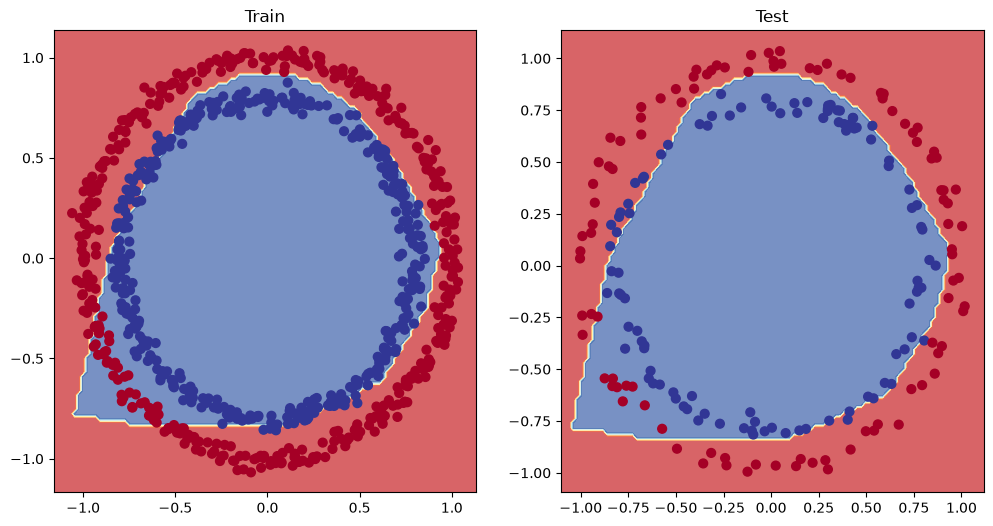

In [18]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model_1, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model_1, X_test, y_test)